In [22]:
import numpy as np
import pandas as pd
from jupyter_output_parse import _parse_components, parse_training_log

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def _get_series(exp_dict, phase: str):
    """Return sorted epochs, train_losses, val_losses for a given phase."""
    if phase not in exp_dict:
        return np.array([]), np.array([]), np.array([])
    epochs = sorted(exp_dict[phase].keys())
    if not epochs:
        return np.array([]), np.array([]), np.array([])
    train = [exp_dict[phase][e].get("train_loss", np.nan) for e in epochs]
    val   = [exp_dict[phase][e].get("valid_loss", np.nan) for e in epochs]
    return np.asarray(epochs), np.asarray(train, float), np.asarray(val, float)

def plot_losses_across_models(
    results,
    model_ids=None,
    use_both_phases=True,
    logy=True,
    show=True,
    save_dir=None,
):
    """
    Plot train/val loss vs epoch for 4 models (experiments).

    Args:
      results: output of parse_training_log(...)
      model_ids: list of experiment indices to plot (default: first 4 sorted)
      use_both_phases: if True, concatenate TRAINING + REFINEMENT into one x-axis
                       by offsetting refinement epochs after training.
      logy: if True, use log scale for y (losses often span orders of magnitude)
      save_dir: if not None, saves PNGs there (one per model)
    """
    # pick 4 models by default
    if model_ids is None:
        model_ids = sorted(results.keys())
    else:
        model_ids = list(model_ids)[:4]

    for exp in model_ids:
        exp_dict = results[exp]

        # --- build the x/y series ---
        if use_both_phases:
            e_tr, tr_tr, va_tr = _get_series(exp_dict, "TRAINING")
            e_rf, tr_rf, va_rf = _get_series(exp_dict, "REFINEMENT")

            if e_tr.size == 0 and e_rf.size == 0:
                print(f"[skip] EXPERIMENT {exp}: no epochs found.")
                continue

            # Offset refinement epochs so they continue after training
            if e_tr.size > 0:
                offset = int(np.nanmax(e_tr))
                x_tr = e_tr
                x_rf = e_rf + offset + 1 if e_rf.size > 0 else e_rf
            else:
                x_tr = e_tr
                x_rf = e_rf

            # concatenate (keep phase boundaries separate for plotting clarity)
            x_train = np.concatenate([x_tr, x_rf]) if x_rf.size else x_tr
            y_train = np.concatenate([tr_tr, tr_rf]) if x_rf.size else tr_tr
            x_val   = np.concatenate([x_tr, x_rf]) if x_rf.size else x_tr
            y_val   = np.concatenate([va_tr, va_rf]) if x_rf.size else va_tr

            phase_note = "TRAINING (+ offset REFINEMENT)"
        else:
            x_train, y_train, y_val = None, None, None  # quiet linters
            e_tr, tr_tr, va_tr = _get_series(exp_dict, "TRAINING")
            if e_tr.size == 0:
                print(f"[skip] EXPERIMENT {exp}: no TRAINING epochs found.")
                continue
            x_train, y_train, x_val, y_val = e_tr, tr_tr, e_tr, va_tr
            phase_note = "TRAINING only"

        # --- plot ---
        plt.figure(figsize=(8, 5))
        plt.plot(x_train, y_train, label="train")
        plt.plot(x_val,   y_val,   label="validation")

        plt.title(f"EXPERIMENT {exp} loss vs epoch ({phase_note})")
        plt.xlabel("epoch")
        plt.ylabel("loss")
        if logy:
            plt.yscale("log")
        plt.grid(True, which="both", linewidth=0.5, alpha=0.5)
        plt.legend()

        if save_dir is not None:
            from pathlib import Path
            save_dir = Path(save_dir)
            save_dir.mkdir(parents=True, exist_ok=True)
            out = save_dir / f"loss_curves_experiment_{exp}.png"
            plt.savefig(out, dpi=600, bbox_inches="tight")
            print(f"[saved] {out}")

        if show:
            plt.show()
        else:
            plt.close()


In [50]:
import numpy as np
import matplotlib.pyplot as plt

def _get_series(exp_dict, phase: str):
    """Return sorted epochs, train_losses, val_losses for a given phase."""
    if phase not in exp_dict:
        return np.array([]), np.array([]), np.array([])
    epochs = sorted(exp_dict[phase].keys())
    if not epochs:
        return np.array([]), np.array([]), np.array([])
    train = [exp_dict[phase][e].get("train_loss", np.nan) for e in epochs]
    val   = [exp_dict[phase][e].get("valid_loss", np.nan) for e in epochs]
    return np.asarray(epochs), np.asarray(train, float), np.asarray(val, float)

def _build_xy_for_exp(exp_dict, use_both_phases=True):
    """Return x, y_train, y_val for one experiment, optionally TRAINING+offset REFINEMENT."""
    if use_both_phases:
        e_tr, tr_tr, va_tr = _get_series(exp_dict, "TRAINING")
        e_rf, tr_rf, va_rf = _get_series(exp_dict, "REFINEMENT")

        if e_tr.size == 0 and e_rf.size == 0:
            return np.array([]), np.array([]), np.array([])

        if e_tr.size > 0:
            offset = int(np.nanmax(e_tr))
            x_tr = e_tr
            x_rf = e_rf + offset + 1 if e_rf.size > 0 else e_rf
        else:
            x_tr = e_tr
            x_rf = e_rf

        x = np.concatenate([x_tr, x_rf]) if x_rf.size else x_tr
        y_train = np.concatenate([tr_tr, tr_rf]) if x_rf.size else tr_tr
        y_val   = np.concatenate([va_tr, va_rf]) if x_rf.size else va_tr
        return x.astype(int), y_train.astype(float), y_val.astype(float)

    # TRAINING only
    e_tr, tr_tr, va_tr = _get_series(exp_dict, "TRAINING")
    if e_tr.size == 0:
        return np.array([]), np.array([]), np.array([])
    return e_tr.astype(int), tr_tr.astype(float), va_tr.astype(float)

def plot_all_losses_with_mean(
    results,
    model_ids=None,
    use_both_phases=True,
    logy=True,
    show=True,
    save_path=None,
    individual_alpha=0.25,
    mean_linewidth=3.0,
):
    """
    Plot all models' train/val learning curves on ONE plot, plus mean train/val.

    - Individual curves are plotted with low alpha.
    - Mean curves are computed epoch-wise over available models (nanmean).
    """
    # choose which experiments to include
    if model_ids is None:
        model_ids = sorted(results.keys())
    else:
        model_ids = list(model_ids)

    # build per-experiment series
    series = []
    for exp in model_ids:
        x, ytr, yva = _build_xy_for_exp(results[exp], use_both_phases=use_both_phases)
        if x.size == 0:
            print(f"[skip] EXPERIMENT {exp}: no epochs found.")
            continue
        series.append((exp, x, ytr, yva))

    if not series:
        print("[abort] No valid experiments to plot.")
        return

    # common x-axis (union of all epochs)
    all_x = np.unique(np.concatenate([x for _, x, _, _ in series]))
    all_x.sort()

    # align into matrices [n_models, n_epochs] with NaNs for missing epochs
    n_models = len(series)
    n_epochs = all_x.size
    train_mat = np.full((n_models, n_epochs), np.nan, dtype=float)
    val_mat   = np.full((n_models, n_epochs), np.nan, dtype=float)

    # helper: map epoch -> index in all_x
    idx_map = {e: i for i, e in enumerate(all_x)}

    for row, (exp, x, ytr, yva) in enumerate(series):
        cols = [idx_map[int(e)] for e in x]
        train_mat[row, cols] = ytr
        val_mat[row, cols]   = yva

    mean_train = np.nanmean(train_mat, axis=0)
    mean_val   = np.nanmean(val_mat, axis=0)

    phase_note = "TRAINING (+ offset REFINEMENT)" if use_both_phases else "TRAINING only"

    # --- plot ---
    plt.figure(figsize=(9, 6))

    # individual curves
    for (exp, x, ytr, yva) in series:
        plt.plot(x, ytr, alpha=individual_alpha, linewidth=1.0)
        plt.plot(x, yva, alpha=individual_alpha, linewidth=1.0, linestyle="--")

    # mean curves (bold)
    plt.plot(all_x, mean_train, label="mean train", linewidth=mean_linewidth, color='C0')
    plt.plot(all_x, mean_val,   label="mean validation", linewidth=mean_linewidth, linestyle="--", color='orange')

    plt.title(f"Training and Validation Loss for N={len(results)} Models", fontsize=24)
    plt.xlabel("No. Epoch", fontsize=18)
    plt.ylabel("AE-SINDy Loss", fontsize=18)
    if logy:
        plt.yscale("log")
    plt.grid(True, which="both", linewidth=0.5, alpha=0.5)
    plt.legend(fontsize=16)

    if save_path is not None:
        plt.savefig(save_path, dpi=600, bbox_inches="tight")
        print(f"[saved] {save_path}")

    if show:
        plt.show()
    else:
        plt.close()


In [ ]:
# ----------------- Usage -----------------
# 1) Parse
results = parse_training_log("251214_DCL_like_data_training_log.txt")

# 2) Plot first 4 experiments found
plot_losses_across_models(results, use_both_phases=True, logy=True)

# 3) Or explicitly choose which 4
#plot_losses_across_models(results, model_ids=[0,1,2,3], use_both_phases=True, logy=True)

# 4) Save images
#plot_losses_across_models(results, save_dir="loss_plots", use_both_phases=True, logy=True)

[saved] pics/all_learning_curves_with_mean.png


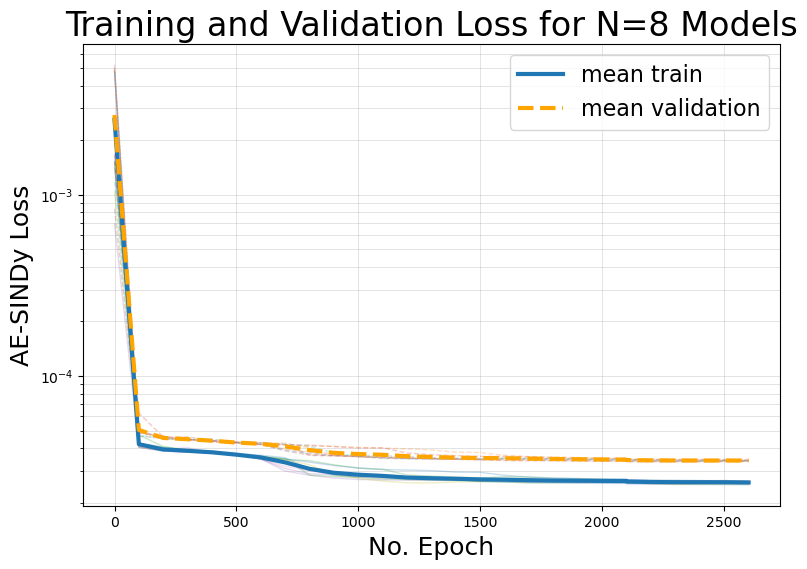

In [51]:
# all experiments in `results`
#plot_all_losses_with_mean(results, use_both_phases=True)
# save to file
plot_all_losses_with_mean(results, save_path="pics/all_learning_curves_with_mean.png")


In [34]:
len(results)

8